In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import re

In [2]:
dfELM = pd.read_csv('../Data/ELM_mutations.csv')
dfACT = pd.read_csv('../Data/DMSactivities.csv')
clinvar = pd.read_csv('../Data/clinvar_missense.csv', index_col=0)

clinvar = clinvar.rename(columns={'Protein change': 'mutation'})

In [3]:
df = dfELM.merge(dfACT, on='mutation', how='left')

In [4]:
df['in_clinvar'] = df['mutation'].isin(clinvar['mutation'])

In [5]:
df = df[(df['mutation'] == 'WT') | df['normalized_activity_score_mean'].notna()]

In [6]:
WT = df.head(1).copy()

/var/folders/s5/pmcccnjn3xscf5d6crplwgx40000gn/T/ipykernel_56840/798931586.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


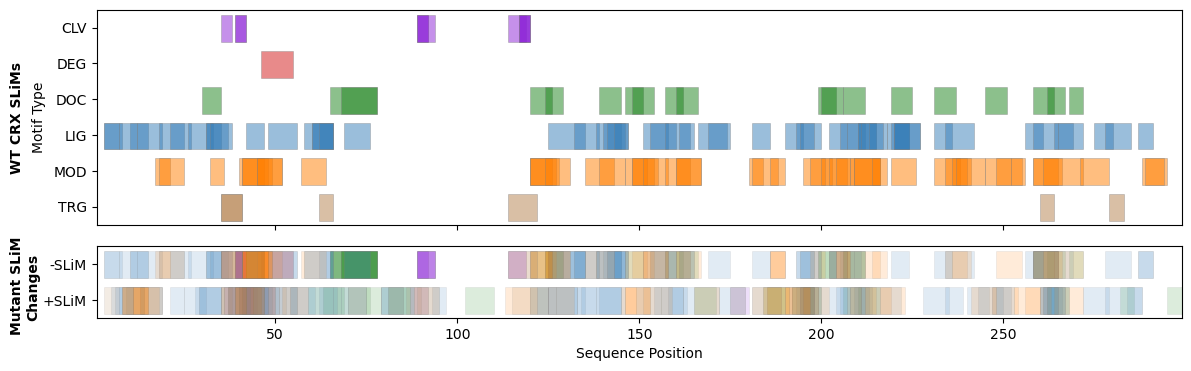

In [9]:
# Extract location ranges from format "###-###"
def parse_locations(loc_string):
    """Parse location string in format '###-###' to list of (start, end) tuples"""
    if pd.isna(loc_string) or loc_string == '':
        return []
    locations = []
    for loc in str(loc_string).split(','):
        match = re.search(r'(\d+)-(\d+)', loc.strip())
        if match:
            locations.append((int(match.group(1)), int(match.group(2))))
    return locations

def get_motif_deltas_by_type(wt_row, mut_row):
    """Compare WT and mutant motif locations and return added/deleted regions by motif type"""
    added_by_type = {motif: [] for motif in motif_types}
    deleted_by_type = {motif: [] for motif in motif_types}
    
    for motif_col in motif_types:
        wt_locs = set(parse_locations(wt_row[motif_col].values[0]))
        mut_locs = set(parse_locations(mut_row[motif_col].values[0]))
        
        # Find added and deleted regions for this motif type
        for loc in mut_locs - wt_locs:
            added_by_type[motif_col].append(loc)
        for loc in wt_locs - mut_locs:
            deleted_by_type[motif_col].append(loc)
    
    return added_by_type, deleted_by_type

# Define motif types and colors
motif_types = ['CLV_locations', 'DEG_locations', 'DOC_locations', 
               'LIG_locations', 'MOD_locations', 'TRG_locations']
colors = ["#8c22d7", "#d21717", "#1a821a", '#377eb8', '#ff7f00', "#b4804d"]
color_map = dict(zip(motif_types, colors))

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 4), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.15})

# Collect all deltas from clinvar mutations by type
all_added_by_type = {motif: [] for motif in motif_types}
all_deleted_by_type = {motif: [] for motif in motif_types}

# Filter clinvar for only in_clinvar == True
clinvar_filtered = clinvar[clinvar.get('in_clinvar', True) == True] if 'in_clinvar' in clinvar.columns else clinvar

for protein_change in clinvar_filtered['mutation']:
    # Find corresponding mutation in df
    mut_row = df[df['mutation'] == protein_change]
    if not mut_row.empty:
        # Check if mutation has in_clinvar == True
        if mut_row['in_clinvar'].values[0]:
            added_by_type, deleted_by_type = get_motif_deltas_by_type(WT, mut_row)
            for motif in motif_types:
                all_added_by_type[motif].extend(added_by_type[motif])
                all_deleted_by_type[motif].extend(deleted_by_type[motif])

# Plot each motif type in its own row on TOP subplot
for i, (motif, color) in enumerate(zip(motif_types, colors)):
    locations = parse_locations(WT[motif].values[0])

    for (start, end) in locations:
        width = end - start
        rect = plt.Rectangle((start, i - .35), width, .75, 
                            facecolor=color, edgecolor='grey', linewidth=0.5, alpha=0.5)
        ax1.add_patch(rect)

ax1.text(-0.06, .35, 'Motif Type', fontsize=10, transform=ax1.transAxes, rotation=90)
ax1.text(-0.08, .25, 'WT CRX SLiMs', fontweight='bold', fontsize=10, transform=ax1.transAxes, rotation=90)

# Set axes for top subplot
ax1.set_xlim(1, 299)
ax1.set_ylim(-0.5, len(motif_types) - 0.5)
ax1.set_yticks(list(range(len(motif_types))))
ax1.set_yticklabels([m.replace('_locations', '') for m in motif_types])
ax1.invert_yaxis()
ax1.set_xticklabels([])  # Remove x-tick labels from top plot

# Plot -SLiM row (row 0) on BOTTOM subplot - colored by motif type
for motif in motif_types:
    for (start, end) in all_deleted_by_type[motif]:
        width = end - start
        rect = plt.Rectangle((start, -0.35), width, 0.75, 
                            facecolor=color_map[motif], edgecolor='grey', linewidth=0.5, alpha=0.15)
        ax2.add_patch(rect)

# Plot +SLiM row (row 1) on BOTTOM subplot - colored by motif type
for motif in motif_types:
    for (start, end) in all_added_by_type[motif]:
        width = end - start
        rect = plt.Rectangle((start, 0.65), width, 0.75, 
                            facecolor=color_map[motif], edgecolor='grey', linewidth=0.5, alpha=0.15)
        ax2.add_patch(rect)

ax2.text(-0.08, -.2, 'Mutant SLiM', fontweight='bold', fontsize=10, transform=ax2.transAxes, rotation=90)
ax2.text(-0.065, 0, 'Changes', fontweight='bold', fontsize=10, transform=ax2.transAxes, rotation=90)

# Set axes for bottom subplot
ax2.set_xlim(1, 299)
ax2.set_ylim(-0.5, 1.5)
ax2.set_xlabel('Sequence Position')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['-SLiM', '+SLiM'])
ax2.invert_yaxis()

plt.tight_layout()
#plt.savefig('../Graphs/Fig1/SLiMs.svg')

In [10]:
# Count total patches for WT CRX by motif type
total_patches = 0
for motif in motif_types:
    locations = parse_locations(WT[motif].values[0])
    count = len(locations)
    total_patches += count
    print(f"{motif}: {count} patches")

print(f"\nTotal patches for WT CRX: {total_patches}")

CLV_locations: 10 patches
DEG_locations: 1 patches
DOC_locations: 19 patches
LIG_locations: 55 patches
MOD_locations: 48 patches
TRG_locations: 6 patches

Total patches for WT CRX: 139


/var/folders/s5/pmcccnjn3xscf5d6crplwgx40000gn/T/ipykernel_56840/288253209.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


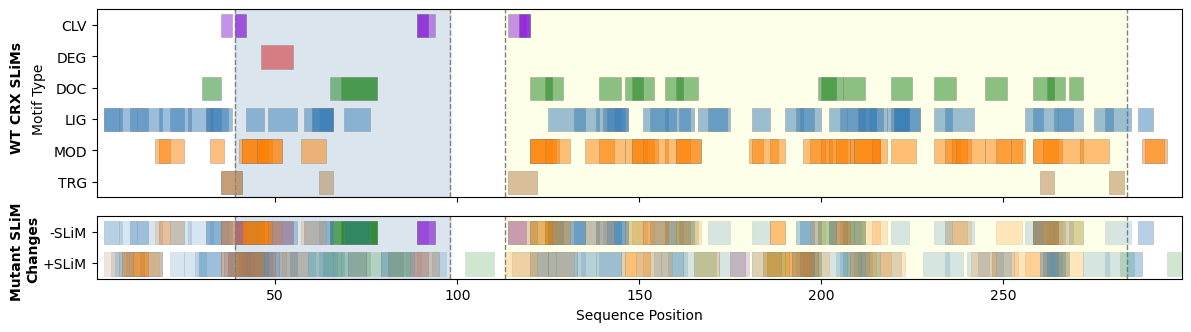

In [14]:
import re

def parse_locations(loc_string):
    if pd.isna(loc_string) or loc_string == '':
        return []
    locations = []
    for loc in str(loc_string).split(','):
        match = re.search(r'(\d+)-(\d+)', loc.strip())
        if match:
            locations.append((int(match.group(1)), int(match.group(2))))
    return locations

def get_motif_deltas_by_type(wt_row, mut_row):
    added_by_type   = {motif: [] for motif in motif_types}
    deleted_by_type = {motif: [] for motif in motif_types}
    for motif_col in motif_types:
        wt_locs  = set(parse_locations(wt_row[motif_col].values[0]))
        mut_locs = set(parse_locations(mut_row[motif_col].values[0]))
        for loc in mut_locs - wt_locs:
            added_by_type[motif_col].append(loc)
        for loc in wt_locs - mut_locs:
            deleted_by_type[motif_col].append(loc)
    return added_by_type, deleted_by_type

# Define motif types and colors
motif_types = ['CLV_locations', 'DEG_locations', 'DOC_locations',
               'LIG_locations', 'MOD_locations', 'TRG_locations']
colors    = ["#8c22d7", "#d21717", "#1a821a", '#377eb8', '#ff7f00', "#b4804d"]
color_map = dict(zip(motif_types, colors))

# Collect all deltas from ClinVar mutations by type
all_added_by_type   = {motif: [] for motif in motif_types}
all_deleted_by_type = {motif: [] for motif in motif_types}

for protein_change in clinvar['mutation']:
    mut_row = df[df['mutation'] == protein_change]
    if not mut_row.empty:
        added_by_type, deleted_by_type = get_motif_deltas_by_type(WT, mut_row)
        for motif in motif_types:
            all_added_by_type[motif].extend(added_by_type[motif])
            all_deleted_by_type[motif].extend(deleted_by_type[motif])

# ── Figure ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 3.5),
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.15})

bg_kwargs  = dict(zorder=0)
vl_kwargs  = dict(color='grey', linestyle='--', linewidth=1, zorder=1)
bg_regions = [(39, 98, '#4981ae'), (113, 284, '#fdff91')]
vlines     = [39, 98, 113, 284]

for ax in (ax1, ax2):
    for x0, x1, c in bg_regions:
        ax.axvspan(x0, x1, alpha=0.2, color=c, **bg_kwargs)
    for x in vlines:
        ax.axvline(x=x, **vl_kwargs)

# ── Top subplot: WT SLiMs ────────────────────────────────────────────────────
for i, (motif, color) in enumerate(zip(motif_types, colors)):
    for (start, end) in parse_locations(WT[motif].values[0]):
        ax1.add_patch(plt.Rectangle((start, i - .35), end - start, .75,
                                    facecolor=color, edgecolor='grey',
                                    linewidth=0.5, alpha=0.5))

ax1.text(-0.06, .35, 'Motif Type',     fontsize=10, transform=ax1.transAxes, rotation=90)
ax1.text(-0.08, .25, 'WT CRX SLiMs',  fontweight='bold', fontsize=10,
         transform=ax1.transAxes, rotation=90)
ax1.set_xlim(1, 299)
ax1.set_ylim(-0.5, len(motif_types) - 0.5)
ax1.set_yticks(range(len(motif_types)))
ax1.set_yticklabels([m.replace('_locations', '') for m in motif_types])
ax1.invert_yaxis()
ax1.set_xticklabels([])

# ── Bottom subplot: +SLiM / -SLiM colored by motif type ─────────────────────
for motif in motif_types:
    color = color_map[motif]
    for (start, end) in all_deleted_by_type[motif]:
        ax2.add_patch(plt.Rectangle((start, -0.35), end - start, 0.75,
                                    facecolor=color, edgecolor='grey',
                                    linewidth=0.5, alpha=0.2))
    for (start, end) in all_added_by_type[motif]:
        ax2.add_patch(plt.Rectangle((start, 0.65), end - start, 0.75,
                                    facecolor=color, edgecolor='grey',
                                    linewidth=0.5, alpha=0.2))

ax2.text(-0.08, -.3, 'Mutant SLiM', fontweight='bold', fontsize=10,
         transform=ax2.transAxes, rotation=90)
ax2.text(-0.065, 0,  'Changes',     fontweight='bold', fontsize=10,
         transform=ax2.transAxes, rotation=90)
ax2.set_xlim(1, 299)
ax2.set_ylim(-0.5, 1.5)
ax2.set_xlabel('Sequence Position')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['-SLiM', '+SLiM'])
ax2.invert_yaxis()

plt.tight_layout()
#plt.savefig('../Graphs/Fig1/SLiMs.svg')